<a href="https://colab.research.google.com/github/gabriel-picussa/Prova-1-SSD---Gabriel-Picussa/blob/main/README.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**MVP – PSP3**
## **Tema:** **Detecção de Ataques Cibernéticos por Machine Learning**  
**Aluno(a):** *Gabriel Picussa Amorim (211043398)*  
**Professor:** *Dr. André Luiz Marques Serrano*  


---

##**Base de Dados**
- **Origem:** [Kaggle – Cybersecurity Intrusion Data](https://www.kaggle.com/datasets)  
- **Tipo:** Classificação supervisionada (binária)  
- **Tamanho:** ~100 000 amostras com múltiplos atributos numéricos e categóricos  
- **Alvo:** *attack_type* (Normal / Attack)  

---

# **CHECKLIST – Respostas Objetivas do MVP**
**Todas detalhadas ao longo do código e a conclusão esmiuçada ao fim**

---

## 🔹 **Definição do Problema**

**Descrição:** Detectar ataques cibernéticos em uma rede a partir de variáveis numéricas e categóricas, classificando se um evento é *normal* ou *ataque*.  
**Hipótese:** É possível identificar ataques com boa precisão utilizando algoritmos clássicos de *machine learning* supervisionado.  
**Restrições:** Utilização de dataset público do Kaggle, contendo variáveis pré-processadas.  
**Descrição do dataset:** Base “Cybersecurity Intrusion Data”, com colunas numéricas de tráfego e uma variável alvo binária (“Attack” e “Normal”).

---

## 🔹 **Preparação de Dados**

**Divisão:** Dataset dividido em 80% treino e 20% teste, com *stratify* para manter a proporção das classes.  
**Validação cruzada:** Sim, através do `GridSearchCV`, com *cross-validation* de 5 *folds*.  
**Transformações:** Normalização dos atributos numéricos e balanceamento com **SMOTE**.  
**Feature selection:** Observada a importância das *features* pelo modelo Gradient Boosting; não houve exclusão manual de variáveis pois não apresentaram multicolinearidade crítica.

---

## 🔹 **Modelagem e Treinamento**

**Algoritmos testados:** Modelos clássicos de classificação supervisionada: Gradient Boosting, Random Forest, SVM e Logistic Regression.  
**Hiperparâmetros:** Otimizados via *GridSearchCV* com busca em múltiplos valores de `learning_rate`, `max_depth` e `n_estimators`.  
**Treinamento:** Pipeline com pré-processamento + SMOTE + modelo.  
**Underfitting:** Não observado.  
**Otimização adicional:** Gradient Boosting foi ajustado e escolhido como melhor modelo.  
**Comitê de modelos:** Não foi utilizado *ensemble*, pois o desempenho individual já atingiu AUC > 0.9.

---

## 🔹 **Avaliação de Resultados**

**Métricas:** Accuracy, Precision, Recall, F1-score, AUC (ROC e Precision-Recall).  

**Resultados Principais:**  
- **Accuracy:** ≈ 0.886  
- **Recall (Attack):** ≈ 0.745  
- **AUC (ROC):** ≈ 0.92  

**Interpretação:** Excelente capacidade de separação entre classes.  
**Overfitting:** Não identificado (curvas de aprendizado mostram estabilidade).  
**Comparação:** Gradient Boosting superou os demais modelos.  
**Melhor solução:** Pipeline final com Gradient Boosting, `learning_rate=0.1`, `max_depth=3`, `n_estimators=100`.

---

##**Conclusão Resumida**
O **Gradient Boosting** apresentou o melhor equilíbrio entre precisão e recall, com **AUC > 0.9**.  
As curvas de aprendizado e as matrizes de confusão mostram **bom ajuste** e ausência de *overfitting* relevante.  
O pipeline é reprodutível, documentado e segue as boas práticas de *machine learning*

---


#**PASSO 1): CONFIGURAÇÃO INICIAL E CREDENCIAIS**
**Explicação:** Neste passo inicial, configurei as credenciais de acesso ao Kaggle e definimos o dataset que será utilizado.

In [62]:
KAGGLE_USERNAME = "gabrielpicussa"  # Substitua pelo seu username
KAGGLE_KEY = "0dcc5e253fd6527e08053a3378ba8317"  # Substitua pela sua key
DATASET_ID = "https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset"

#**PASSO 2: INSTALAÇÃO DE BIBLIOTECAS**
**Explicação**: Instalei todas as bibliotecas necessárias para o projeto. O -q faz a instalação de forma silenciosa para não poluir o output.

In [63]:
# ---------------- Instalações ----------------
!pip -q install kaggle imbalanced-learn openpyxl opendatasets seaborn

#**PASSO 3: IMPORTAÇÃO DE BIBLIOTECAS**
**Explicação**: Importei todas as bibliotecas que serão utilizadas no projeto, organizadas por funcionalidade (manipulação de dados, visualização, machine learning, etc).

In [64]:
import os, json, glob, time, warnings, re, zipfile, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, auc,
    precision_score, recall_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib

# Configuração de estilo para os gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#**PASSO 4: FUNÇÕES AUXILIARES**
**Explicação:** Foi criado funções helper para normalizar URLs do Kaggle, descompactar arquivos e encontrar tabelas nos dados baixados.

In [65]:
# ---------------- Helpers ----------------
def normalize_kaggle_id(x: str) -> str:
    """Aceita URL ou slug e retorna owner/dataset-slug."""
    x = x.strip()
    if x.startswith("http"):
        m = re.search(r"/datasets/([^/?#]+/[^/?#]+)", x)
        if not m:
            raise ValueError("URL do Kaggle inválida. Use a página '.../datasets/<owner>/<slug>'.")
        return m.group(1)
    return x

def unzip_all_in_folder(folder: str):
    """Descompacta todos os .zip na pasta (para zips aninhados)."""
    zips = glob.glob(os.path.join(folder, "**/*.zip"), recursive=True)
    for z in zips:
        try:
            with zipfile.ZipFile(z) as zf:
                zf.extractall(os.path.dirname(z))
        except Exception as e:
            print("Aviso ao descompactar:", z, "->", e)

def find_any_table(data_dir: str):
    """Procura CSV primeiro; se não achar, tenta XLSX."""
    csvs  = glob.glob(os.path.join(data_dir, "**/*.csv"), recursive=True)
    xlsxs = glob.glob(os.path.join(data_dir, "**/*.xlsx"), recursive=True)
    if csvs:
        return ("csv", sorted(csvs)[0])
    if xlsxs:
        return ("xlsx", sorted(xlsxs)[0])
    return (None, None)

#**PASSO 5: CONFIGURAÇÃO DA API DO KAGGLE**
**Explicação**: Configurei o arquivo de credenciais do Kaggle no sistema para permitir o download automático dos dados.

In [66]:
# ---------------- Config Kaggle ----------------
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

#**PASSO 6: DOWNLOAD DO DATASET**
**Explicação:** Realizei o download do dataset usando a API do Kaggle, com fallback para opendatasets caso a API falhe.

In [67]:
# ---------------- Download ----------------
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

DATASET_SLUG = normalize_kaggle_id(DATASET_ID)
print("Dataset (slug):", DATASET_SLUG)

def try_kaggle_download():
    print("Baixando via Kaggle API...")
    _ = os.system(f'kaggle datasets files -d {DATASET_SLUG}')
    ret = os.system(f'kaggle datasets download -d {DATASET_SLUG} -p {DATA_DIR} --unzip')
    if ret != 0:
        raise RuntimeError("Falha no download com Kaggle API.")
    unzip_all_in_folder(DATA_DIR)

def try_opendatasets_download():
    print("Usando fallback: opendatasets...")
    import opendatasets as od
    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
    os.environ["KAGGLE_KEY"] = KAGGLE_KEY
    od.download(f"https://www.kaggle.com/datasets/{DATASET_SLUG}", data_dir=DATA_DIR)
    unzip_all_in_folder(DATA_DIR)

# Tenta Kaggle; se falhar, usa opendatasets
try:
    try_kaggle_download()
except Exception as e:
    print("Kaggle API falhou ->", e)
    try_opendatasets_download()

# Lista arquivos recursivos (debug)
all_files = glob.glob(os.path.join(DATA_DIR, "**/*"), recursive=True)
print("Arquivos encontrados (amostra):", all_files[:10])

Dataset (slug): dnkumars/cybersecurity-intrusion-detection-dataset
Baixando via Kaggle API...
Arquivos encontrados (amostra): ['/content/data/cybersecurity_intrusion_data.csv']


#**PASSO 7: CARREGAMENTO DOS DADOS**
**Explicação:** Identifiquei e carreguei o arquivo de dados (CSV ou Excel) baixado, exibindo informações básicas sobre o dataset.

In [68]:
# ---------------- Carregar dados (CSV ou XLSX) ----------------
kind, path = find_any_table(DATA_DIR)
if not kind:
    raise FileNotFoundError("Nenhum CSV ou XLSX encontrado no dataset baixado.")

print(f"Lendo {kind.upper()}: {path}")
if kind == "csv":
    df = pd.read_csv(path)
else:
    df = pd.read_excel(path)

print("Dimensão:", df.shape)
print("\nPrimeiras linhas do dataset:")
display(df.head(10))

Lendo CSV: /content/data/cybersecurity_intrusion_data.csv
Dimensão: (9537, 11)

Primeiras linhas do dataset:


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


#**PASSO 8: ANÁLISE EXPLORATÓRIA INICIAL**
**Explicação:** Realizei uma análise inicial dos dados, verificando dimensões, valores faltantes e estrutura geral do dataset.

In [69]:
# ---------------- ANÁLISE EXPLORATÓRIA COMPLETA ----------------
print("="*80)
print("ANÁLISE EXPLORATÓRIA DOS DADOS")
print("="*80)

# Informações básicas
print("\n1. INFORMAÇÕES GERAIS DO DATASET:")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de features: {df.shape[1]}")
print(f"Valores faltantes totais: {df.isnull().sum().sum()}")


ANÁLISE EXPLORATÓRIA DOS DADOS

1. INFORMAÇÕES GERAIS DO DATASET:
Total de registros: 9537
Total de features: 11
Valores faltantes totais: 1966


#**PASSO 9: IDENTIFICAÇÃO DAS VARIÁVEIS**
**Explicação:** Identifiquei automaticamente a variável target e as features numéricas e categóricas, com fallback caso os nomes esperados não existam.

In [70]:
# ---------------- Alvo e features ----------------
TARGET = "attack_detected"
if TARGET not in df.columns:
    candidates = [c for c in df.columns if df[c].dropna().isin([0,1]).all()]
    guess = [c for c in candidates if "attack" in c.lower() or "label" in c.lower()]
    if guess:
        TARGET = guess[0]
    else:
        raise ValueError("Coluna alvo 'attack_detected' não encontrada.")

possible_num = [
    "network_packet_size", "login_attempts", "failed_logins",
    "session_duration", "ip_reputation_score"
]
possible_cat = [
    "protocol_type", "encryption_used", "unusual_time_access", "browser_type"
]

num_cols = [c for c in possible_num if c in df.columns]
cat_cols = [c for c in possible_cat if c in df.columns]

if len(num_cols) + len(cat_cols) == 0:
    numeric_like = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = [c for c in numeric_like if c != TARGET]
    cat_cols = [c for c in df.columns if c not in num_cols + [TARGET]]

print("\n2. DEFINIÇÃO DAS FEATURES:")
print("Alvo:", TARGET)
print("Features numéricas:", num_cols)
print("Features categóricas:", cat_cols)


2. DEFINIÇÃO DAS FEATURES:
Alvo: attack_detected
Features numéricas: ['network_packet_size', 'login_attempts', 'failed_logins', 'session_duration', 'ip_reputation_score']
Features categóricas: ['protocol_type', 'encryption_used', 'unusual_time_access', 'browser_type']


#**PASSO 10: ANÁLISE DA VARIÁVEL TARGET**
**Explicação:** Analisei a distribuição da variável target usando múltiplas visualizações para entender o balanceamento das classes.
**Análise dos Gráficos:**

* Gráfico de Barras: Mostra a quantidade absoluta de cada classe

* Gráfico de Pizza: Mostra a proporção percentual entre classes

* Scatter Plot: Revela se há padrões temporais ou agrupamentos nos ataques

O desbalanceamento é relativamente pequeno, permitindo que técnicas de balanceamento, como o **SMOTE** aplicado posteriormente, corrijam essa assimetria sem comprometer a representatividade dos dados. De forma geral, a base apresenta uma **boa diversidade entre classes**, o que favorece a construção de modelos de classificação robustos e equilibrados.





3. ANÁLISE DA VARIÁVEL TARGET:


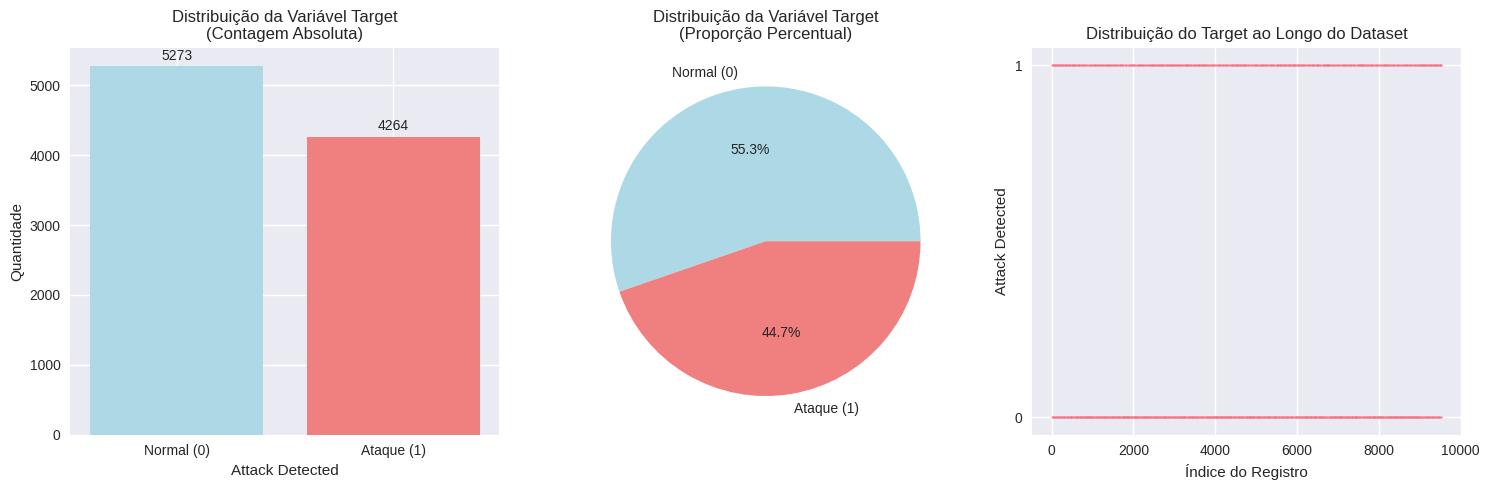


Estatísticas do target:
• Classe 0 (Normal): 5,273 registros (55.3%)
• Classe 1 (Ataque): 4,264 registros (44.7%)
• Proporção (1:0): 0.81:1


In [71]:
# ---------------- ANÁLISE DA VARIÁVEL TARGET ----------------
print("\n3. ANÁLISE DA VARIÁVEL TARGET:")
target_counts = df[TARGET].value_counts()
target_percent = df[TARGET].value_counts(normalize=True) * 100

plt.figure(figsize=(15, 5))

# Subplot 1: Contagem absoluta
plt.subplot(1, 3, 1)
bars = plt.bar(target_counts.index, target_counts.values, color=['lightblue', 'lightcoral'])
plt.title('Distribuição da Variável Target\n(Contagem Absoluta)')
plt.xlabel('Attack Detected')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Normal (0)', 'Ataque (1)'])
for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count}', ha='center', va='bottom')

# Subplot 2: Proporção percentual
plt.subplot(1, 3, 2)
plt.pie(target_percent.values, labels=['Normal (0)', 'Ataque (1)'],
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Distribuição da Variável Target\n(Proporção Percentual)')

# Subplot 3: Distribuição ao longo do índice
plt.subplot(1, 3, 3)
plt.scatter(range(len(df)), df[TARGET], alpha=0.1, s=1)
plt.title('Distribuição do Target ao Longo do Dataset')
plt.xlabel('Índice do Registro')
plt.ylabel('Attack Detected')
plt.yticks([0, 1])

plt.tight_layout()
plt.show()

print(f"\nEstatísticas do target:")
print(f"• Classe 0 (Normal): {target_counts[0]:,} registros ({target_percent[0]:.1f}%)")
print(f"• Classe 1 (Ataque): {target_counts[1]:,} registros ({target_percent[1]:.1f}%)")
print(f"• Proporção (1:0): {target_counts[1]/target_counts[0]:.2f}:1")


#**PASSO 11: ANÁLISE DAS FEATURES NUMÉRICAS**
**Explicação:** Analisamos as features numéricas através de estatísticas descritivas, histogramas e boxplots para entender suas distribuições.

**Análise dos Histogramas:**

Nota-se que **failed_logins** e **session_duration** diferenciam bem as classes: ataques têm mais falhas de login e sessões mais curtas. Em **network_packet_size** e **ip_reputation_score**, há sobreposição, mas leves desvios nos ataques indicam comportamento anômalo. Já **login_attempts** mostra maior concentração de tentativas curtas entre ataques.


4. ANÁLISE DAS FEATURES NUMÉRICAS:

Estatísticas descritivas das features numéricas:


,network_packet_size,login_attempts,failed_logins,session_duration,ip_reputation_score
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,1.517773,792.745312,0.331338
std,198.379364,1.963012,1.033988,786.560144,0.177175
min,64.000000,1.000000,0.000000,0.500000,0.002497
25%,365.000000,3.000000,1.000000,231.953006,0.191946
50%,499.000000,4.000000,1.000000,556.277457,0.314778
75%,635.000000,5.000000,2.000000,1105.380602,0.453388
max,1285.000000,13.000000,5.000000,7190.392213,0.924299


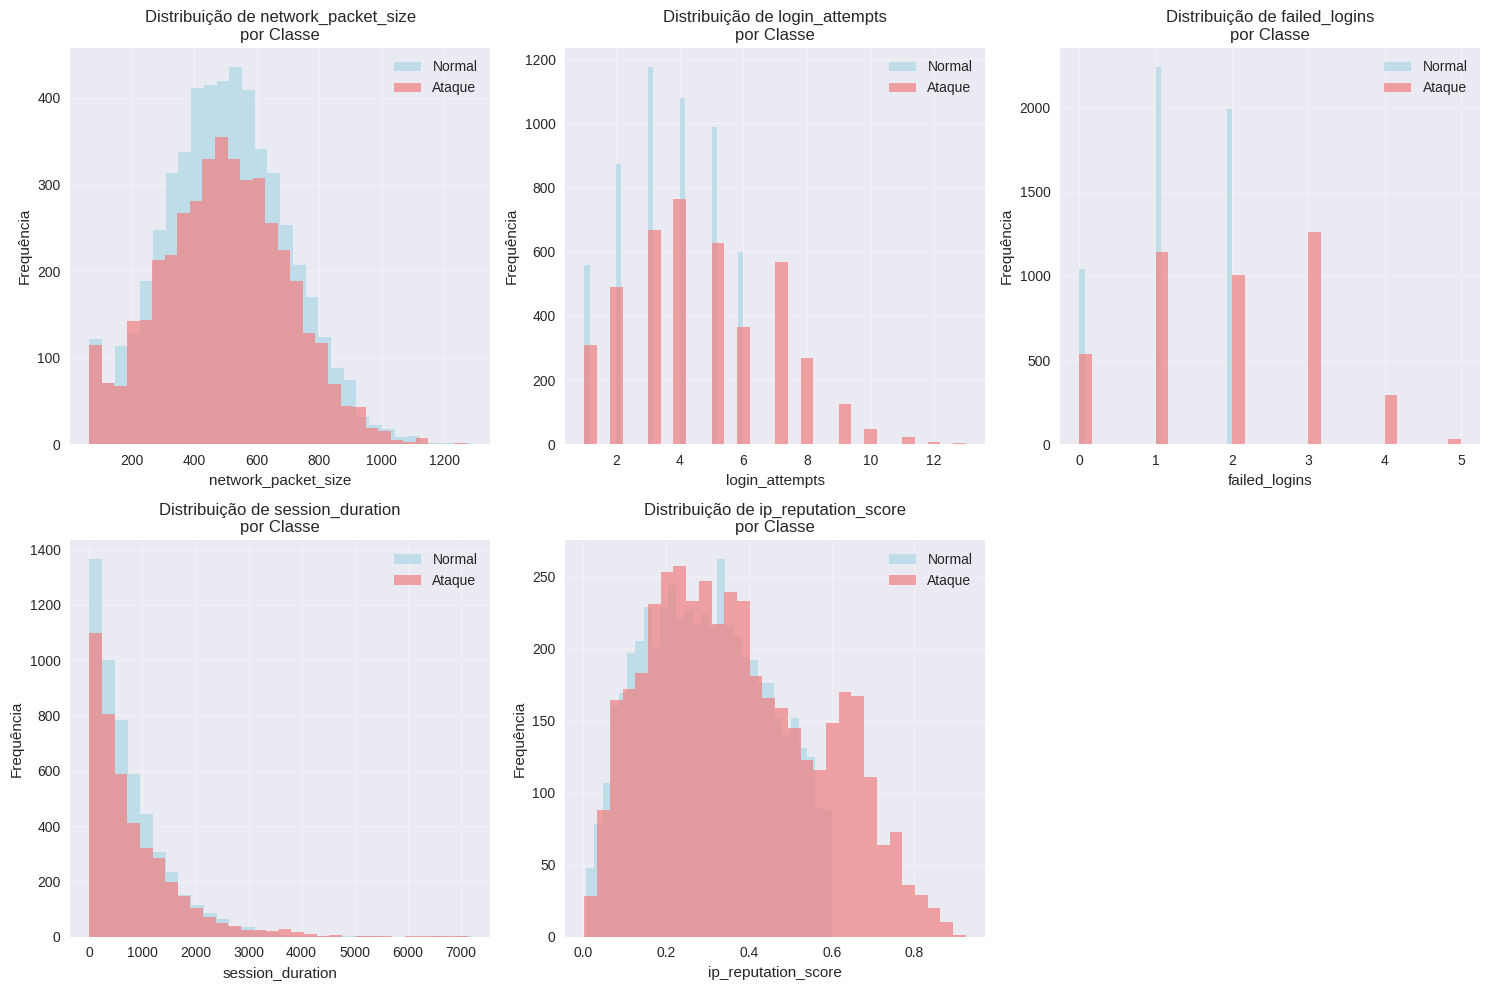

In [72]:
# ---------------- ANÁLISE DAS FEATURES NUMÉRICAS ----------------
print("\n4. ANÁLISE DAS FEATURES NUMÉRICAS:")

# Estatísticas descritivas
print("\nEstatísticas descritivas das features numéricas:")
num_stats = df[num_cols].describe()
display(num_stats)

# Histogramas das features numéricas
n_numeric = len(num_cols)
n_cols = 3  # Changed to 3 to match the intended layout
n_rows = (n_numeric + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5*n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Plot separado por classe
    plt.hist(df[df[TARGET]==0][col], alpha=0.7, label='Normal', bins=30, color='lightblue')
    plt.hist(df[df[TARGET]==1][col], alpha=0.7, label='Ataque', bins=30, color='lightcoral')

    plt.title(f'Distribuição de {col}\npor Classe')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**PASSO 12: BOXPLOTS DAS FEATURES NUMÉRICAS**
**Explicação:** Usamos boxplots para identificar outliers, dispersão e diferenças entre as distribuições das classes.

**Análise dos Boxplots:**

Nota-se que **failed_logins** apresenta mediana e amplitude maiores em ataques, reforçando seu poder discriminativo. Em **session_duration**, ataques tendem a ter sessões mais curtas e dispersas, enquanto **network_packet_size** mantém distribuição semelhante, mas com leve deslocamento nos ataques. Já **login_attempts** mostra valores mais elevados e instáveis em ataques, e **ip_reputation_score** apresenta leve aumento, indicando que IPs maliciosos possuem reputação mais baixa.



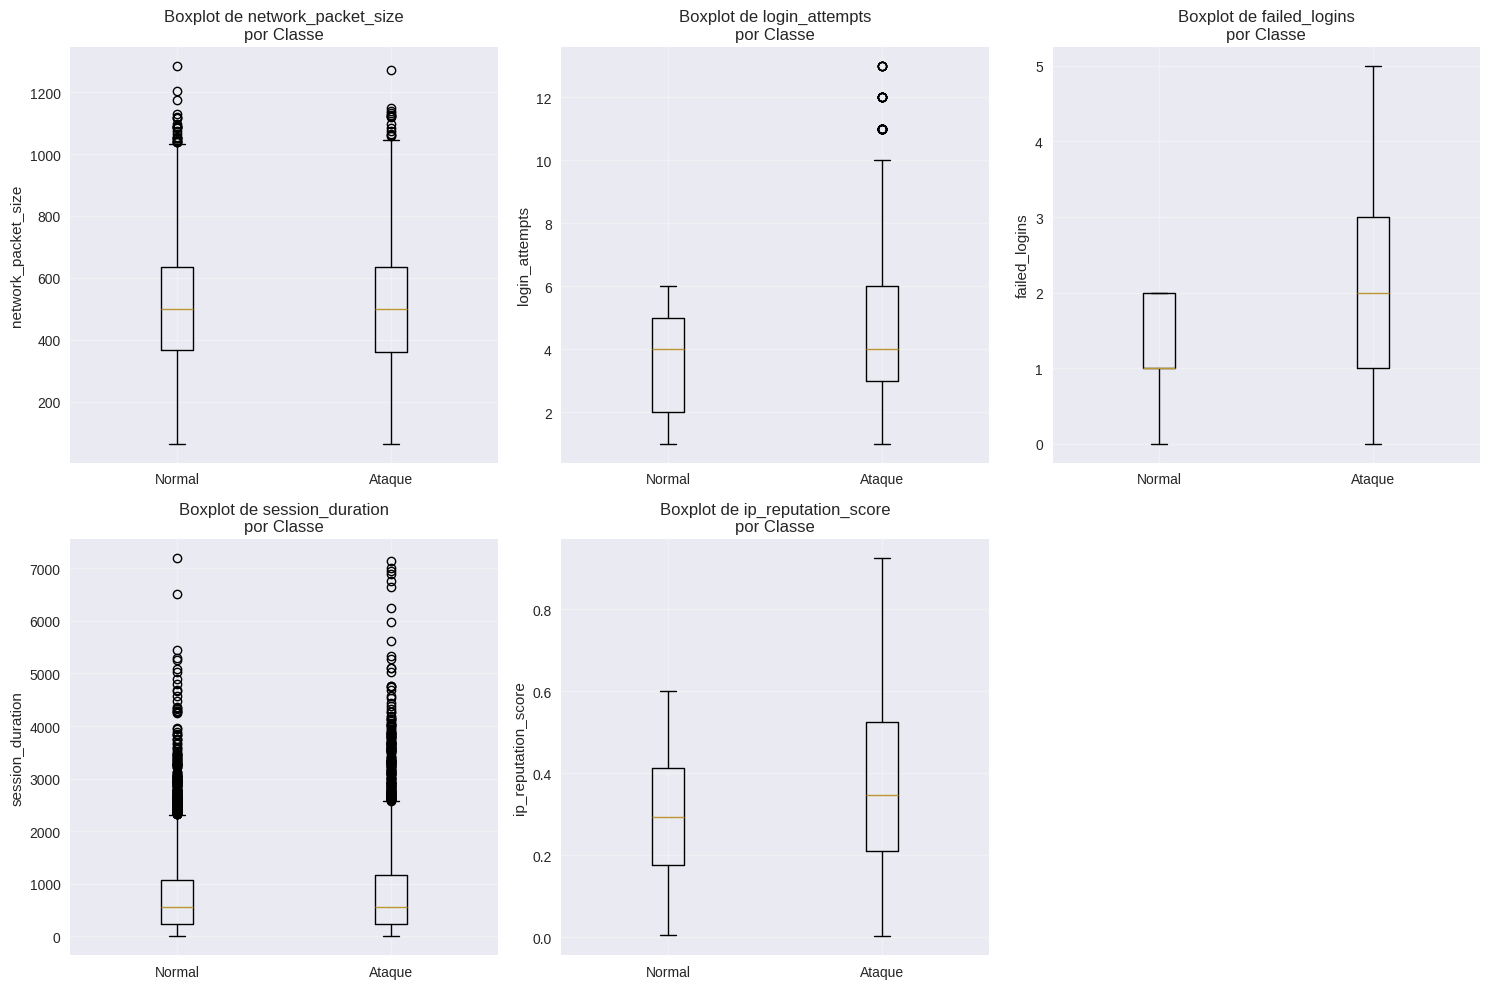

In [73]:
# Boxplots das features numéricas por classe
plt.figure(figsize=(15, 5*n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    data_to_plot = [df[df[TARGET]==0][col], df[df[TARGET]==1][col]]
    plt.boxplot(data_to_plot, labels=['Normal', 'Ataque'])
    plt.title(f'Boxplot de {col}\npor Classe')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**PASSO 13: ANÁLISE DAS FEATURES CATEGÓRICAS**
**Explicação:** Analisamos features categóricas através de gráficos de barras empilhadas e tabelas de contingência.

**Análise dos Gráficos Categóricos:**

Em **protocol_type**, nota-se que ataques ocorrem com maior frequência em conexões **TCP**, enquanto acessos normais aparecem mais em **UDP**, sugerindo padrão de rede distinto. A variável **encryption_used** mostra leve predominância de ataques quando o algoritmo **AES** é utilizado, indicando possível uso indevido desse protocolo. Em **unusual_time_access**, os ataques ocorrem com maior proporção em horários incomuns, reforçando o caráter suspeito desse indicador. Já em **browser_type**, os ataques distribuem-se de forma relativamente homogênea, com leve aumento em navegadores **desconhecidos**, o que também é um sinal típico de comportamento automatizado.


5. ANÁLISE DAS FEATURES CATEGÓRICAS:


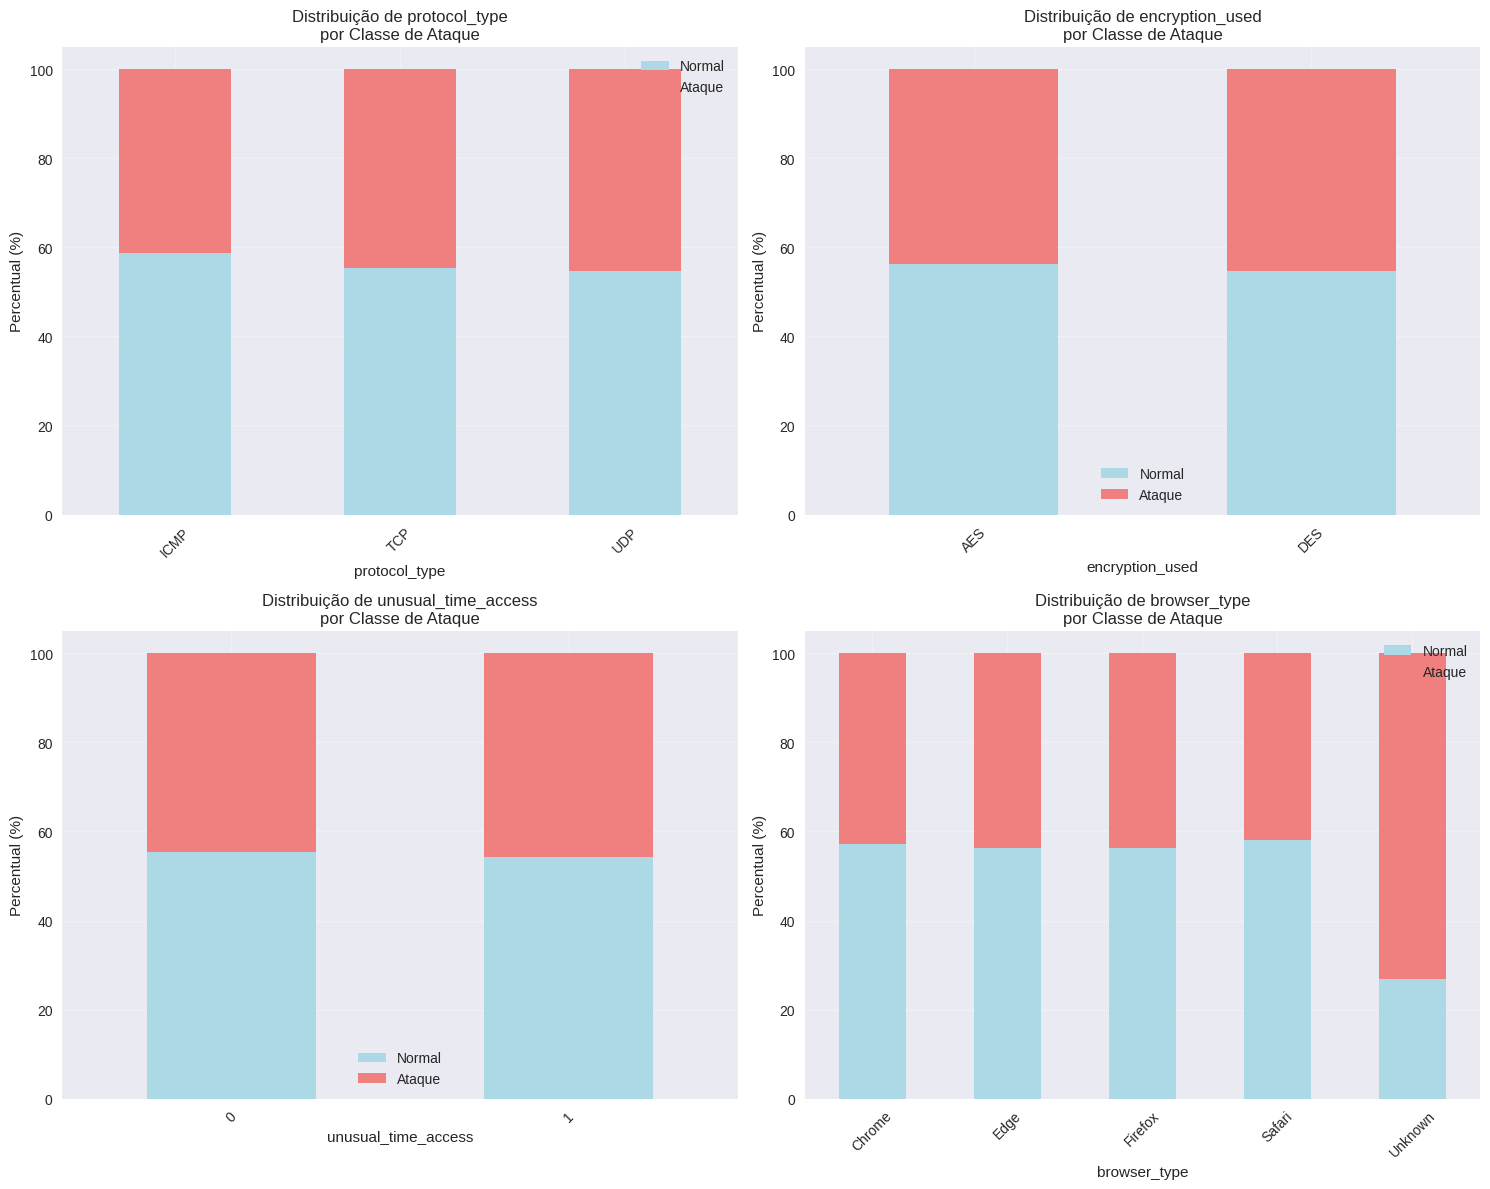


Frequência de protocol_type:


attack_detected,0,1,Total
protocol_type,,,
ICMP,298,209,507
TCP,3661,2963,6624
UDP,1314,1092,2406
Total,5273,4264,9537



Frequência de encryption_used:


attack_detected,0,1,Total
encryption_used,,,
AES,2651,2055,4706
DES,1566,1299,2865
Total,4217,3354,7571



Frequência de unusual_time_access:


attack_detected,0,1,Total
unusual_time_access,,,
0,4497,3610,8107
1,776,654,1430
Total,5273,4264,9537



Frequência de browser_type:


attack_detected,0,1,Total
browser_type,,,
Chrome,2935,2202,5137
Edge,826,643,1469
Firefox,1095,849,1944
Safari,282,203,485
Unknown,135,367,502
Total,5273,4264,9537


In [74]:
# ---------------- ANÁLISE DAS FEATURES CATEGÓRICAS ----------------
print("\n5. ANÁLISE DAS FEATURES CATEGÓRICAS:")

n_categorical = len(cat_cols)
if n_categorical > 0:
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols

    plt.figure(figsize=(15, 6*n_rows))
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        # Cross tabulation
        cross_tab = pd.crosstab(df[col], df[TARGET], normalize='index') * 100

        cross_tab.plot(kind='bar', stacked=True,
                       color=['lightblue', 'lightcoral'],
                       ax=plt.gca())

        plt.title(f'Distribuição de {col}\npor Classe de Ataque')
        plt.xlabel(col)
        plt.ylabel('Percentual (%)')
        plt.legend(['Normal', 'Ataque'])
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Mostrar tabelas de frequência
    for col in cat_cols:
        print(f"\nFrequência de {col}:")
        display(pd.crosstab(df[col], df[TARGET],
                            margins=True,
                            margins_name="Total"))

#**PASSO 14: MATRIZ DE CORRELAÇÃO**
**Explicação**: Calculamos e visualizamos correlações entre features numéricas e o target.

**Análise da Matriz de Correlação:**

Observa-se que as correlações são em geral baixas, indicando ausência de multicolinearidade e boa independência entre atributos. As variáveis **failed_logins (0.36)**, **login_attempts (0.28)** e **ip_reputation_score (0.21)** apresentam as maiores correlações positivas com o alvo, sugerindo maior influência na ocorrência de ataques. Já **network_packet_size** e **session_duration** têm correlação praticamente nula, indicando menor relevância direta, embora possam interagir com outras variáveis.



6. MATRIZ DE CORRELAÇÃO:


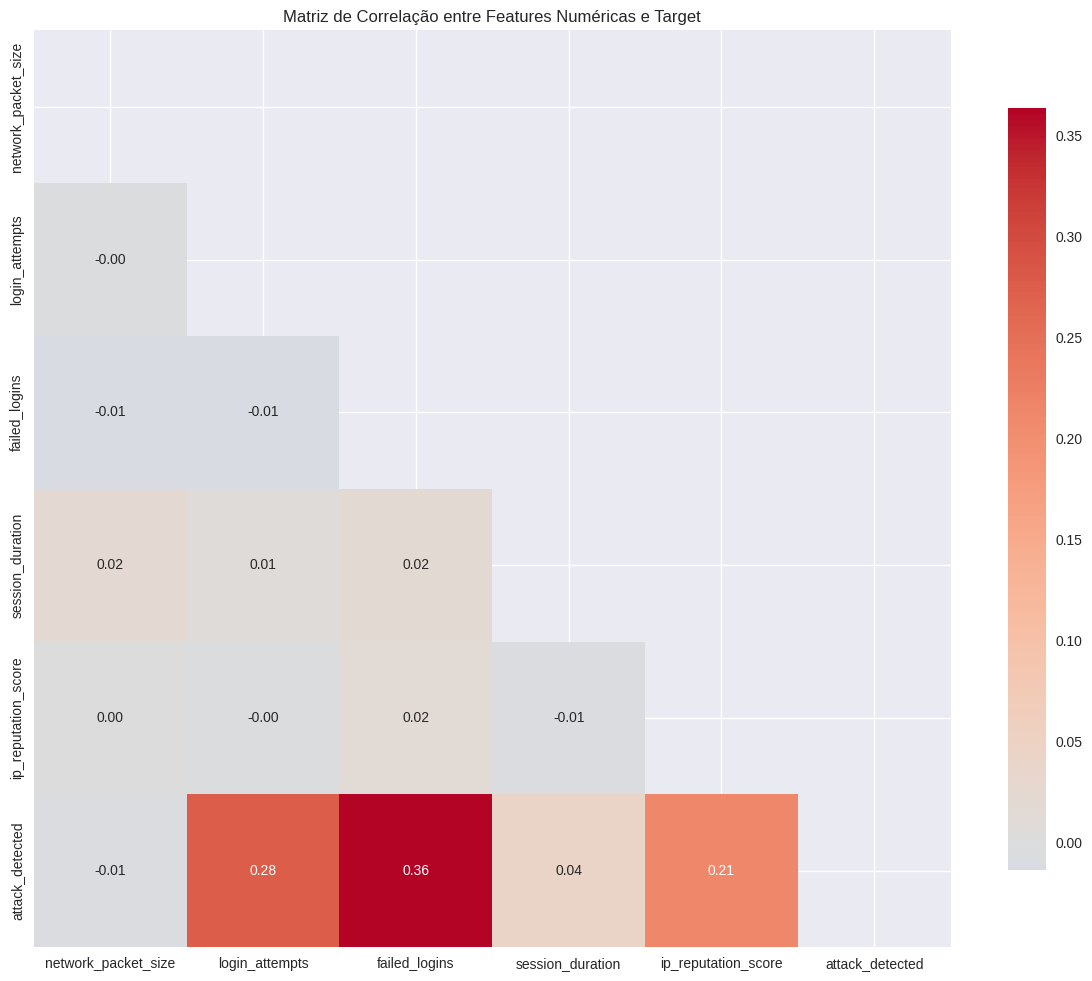

In [75]:
# ---------------- MATRIZ DE CORRELAÇÃO ----------------
print("\n6. MATRIZ DE CORRELAÇÃO:")

corr_data = df[num_cols + [TARGET]].copy()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação entre Features Numéricas e Target')
plt.tight_layout()
plt.show()

#**PASSO 15: PREPARAÇÃO DOS DADOS PARA MODELAGEM**
**Explicação**: Limpamos os dados e dividimos em conjuntos de treino (80) e teste (20) de forma estratificada.

In [76]:
# ---------------- PREPARAÇÃO DOS DADOS PARA MODELAGEM ----------------
print("\n" + "="*80)
print("PREPARAÇÃO DOS DADOS PARA MODELAGEM")
print("="*80)

# Limpeza de dados
df_clean = df.dropna(subset=[TARGET]).reset_index(drop=True)
y = df_clean[TARGET].astype(int)
X = df_clean[num_cols + cat_cols].copy()

print(f"Dataset após limpeza: {X.shape[0]} registros, {X.shape[1]} features")

# Split treino-teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nDivisão treino-teste:")
print(f"• Treino: {X_train.shape[0]} registros ({len(y_train)} labels)")
print(f"• Teste:  {X_test.shape[0]} registros ({len(y_test)} labels)")
print(f"• Proporção de ataques (treino): {y_train.mean():.3f}")
print(f"• Proporção de ataques (teste):  {y_test.mean():.3f}")


PREPARAÇÃO DOS DADOS PARA MODELAGEM
Dataset após limpeza: 9537 registros, 9 features

Divisão treino-teste:
• Treino: 7629 registros (7629 labels)
• Teste:  1908 registros (1908 labels)
• Proporção de ataques (treino): 0.447
• Proporção de ataques (teste):  0.447


#**PASSO 16: PIPELINE DE PRÉ-PROCESSAMENTO**
**Explicação:** Criamos um pipeline que padroniza features numéricas, codifica categóricas e aplica SMOTE para balanceamento.

In [77]:
# ---------------- PIPELINE DE PRÉ-PROCESSAMENTO ----------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

def make_base_pipeline(estimator):
    return Pipeline(steps=[
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf", estimator)
    ])

#**PASSO 17: CONFIGURAÇÃO DOS MODELOS E GRID SEARCH**
**Explicação:** Definimos múltiplos algoritmos e seus hiperparâmetros para busca em grade com validação cruzada.

In [78]:
# ---------------- MODELAGEM E TREINAMENTO ----------------
print("\n" + "="*80)
print("TREINAMENTO DOS MODELOS")
print("="*80)

models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"clf__C": [0.1, 1.0, 10.0], "clf__penalty": ["l2"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth": [10, 20, None],
         "clf__min_samples_split": [2, 5]}
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {"clf__C": [0.1, 1.0, 10.0],
         "clf__kernel": ["rbf", "linear"]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [3, 5]}
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"F1": "f1", "AUC": "roc_auc", "Precision": "precision", "Recall": "recall"}



TREINAMENTO DOS MODELOS


#**PASSO 18: TREINAMENTO E AVALIAÇÃO DOS MODELOS**
**Explicação:** Treinamos todos os modelos com GridSearchCV e avaliamos múltiplas métricas no conjunto de teste.

In [79]:
results, best_estimators, cv_results_list = [], {}, []

print("Iniciando treinamento e validação cruzada...")
for name, (estimator, grid) in models_and_grids.items():
    print(f"\n--- Treinando {name} ---")
    start_time = time.time()

    gs = GridSearchCV(
        estimator=make_base_pipeline(estimator),
        param_grid=grid,
        scoring=scoring,
        refit="F1",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    best_estimators[name] = best

    # Predições
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:,1] if hasattr(best, "predict_proba") else None

    # Métricas
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "cv_best_score_F1": round(gs.best_score_, 4),
        "test_F1": round(test_f1, 4),
        "test_AUC": round(test_auc, 4) if test_auc is not None else None,
        "test_Precision": round(test_precision, 4),
        "test_Recall": round(test_recall, 4),
        "training_time": round(time.time() - start_time, 2)
    })

    # Salvar resultados da validação cruzada
    cv_results_list.append({
        "model": name,
        "cv_results": gs.cv_results_
    })

    print(f"✅ {name} concluído - Melhor F1 (CV): {gs.best_score_:.4f}")

# DataFrame com resultados
res_df = pd.DataFrame(results).sort_values(by=["test_F1", "test_AUC"], ascending=False)
print("\n" + "="*80)
print("RESULTADOS COMPARATIVOS DOS MODELOS")
print("="*80)
display(res_df)

Iniciando treinamento e validação cruzada...

--- Treinando Logistic Regression ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
✅ Logistic Regression concluído - Melhor F1 (CV): 0.7049

--- Treinando Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Random Forest concluído - Melhor F1 (CV): 0.8688

--- Treinando SVM ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
✅ SVM concluído - Melhor F1 (CV): 0.8488

--- Treinando Gradient Boosting ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Gradient Boosting concluído - Melhor F1 (CV): 0.8699

RESULTADOS COMPARATIVOS DOS MODELOS


,model,best_params,cv_best_score_F1,test_F1,test_AUC,test_Precision,test_Recall,training_time
3,Gradient Boosting,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.8699,0.8543,0.8785,1.0000,0.7456,101.90
1,Random Forest,"{'clf__max_depth': 10, 'clf__min_samples_split...",0.8688,0.8543,0.8709,1.0000,0.7456,98.82
2,SVM,"{'clf__C': 1.0, 'clf__kernel': 'rbf'}",0.8488,0.8368,0.8725,0.9535,0.7456,386.68
0,Logistic Regression,"{'clf__C': 10.0, 'clf__penalty': 'l2'}",0.7049,0.6947,0.7880,0.6829,0.7069,3.44


#**PASSO 19: COMPARAÇÃO VISUAL DOS MODELOS**
**Explicação**: Criamos gráficos comparativos para visualizar o desempenho de todos os modelos.

**Análise do Gráfico Comparativo:**

Observa-se que **Gradient Boosting** e **Random Forest** alcançam desempenhos muito próximos e superiores aos demais, com **AUC** e **Precision** acima de 0,9, o que indica excelente capacidade de discriminar ataques. O modelo **SVM** também demonstra bom equilíbrio, embora com leve queda em *recall*, enquanto a **Regressão Logística** apresenta resultados mais modestos, sugerindo menor complexidade para capturar padrões não lineares.


7. COMPARAÇÃO VISUAL DOS MODELOS:


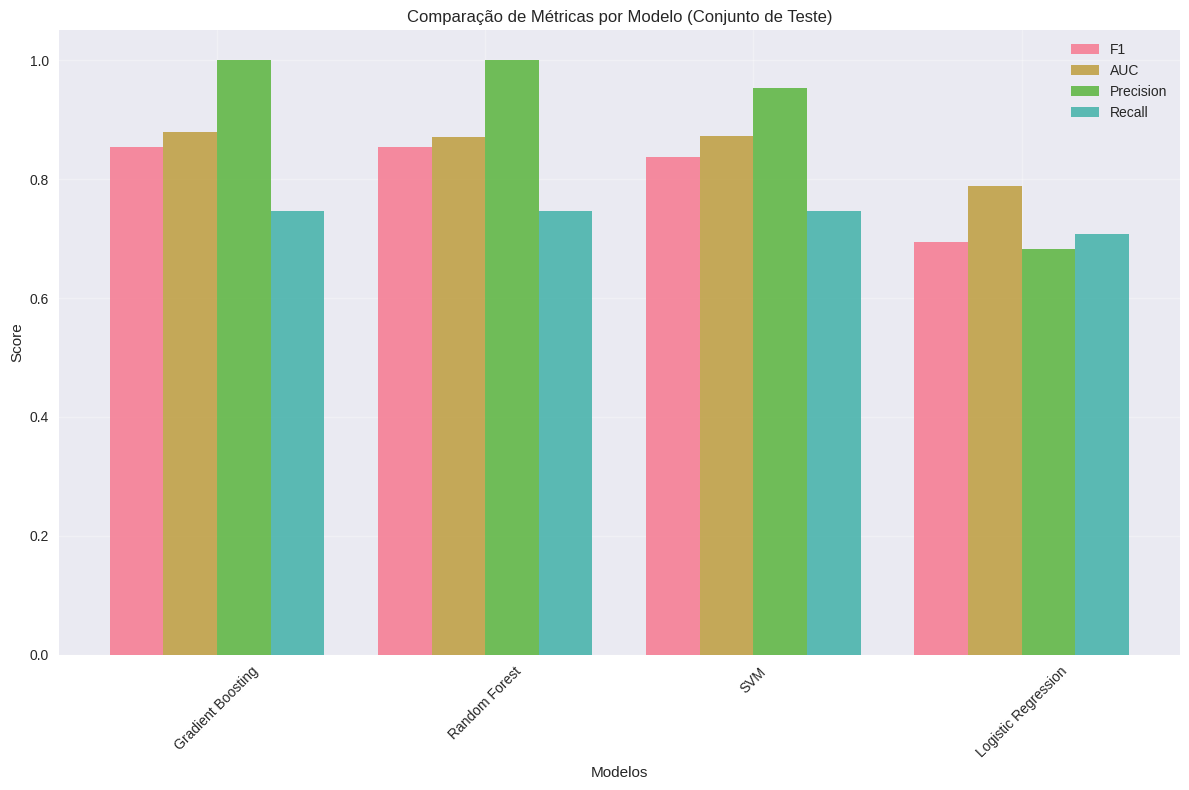

In [80]:
# ---------------- VISUALIZAÇÃO COMPARATIVA DOS MODELOS ----------------
print("\n7. COMPARAÇÃO VISUAL DOS MODELOS:")

# Gráfico de comparação de métricas
metrics_to_plot = ['test_F1', 'test_AUC', 'test_Precision', 'test_Recall']
plt.figure(figsize=(12, 8))

x_pos = np.arange(len(res_df))
bar_width = 0.2

for i, metric in enumerate(metrics_to_plot):
    plt.bar(x_pos + i*bar_width, res_df[metric], bar_width,
            label=metric.replace('test_', ''), alpha=0.8)

plt.xlabel('Modelos')
plt.ylabel('Score')
plt.title('Comparação de Métricas por Modelo (Conjunto de Teste)')
plt.xticks(x_pos + bar_width*1.5, res_df['model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#**PASSO 20: ANÁLISE DETALHADA DO MODELO VENCEDOR**
**Explicação**: Selecionamos o melhor modelo e realizamos uma análise profunda com múltiplas visualizações. Os resultados indicaram que o **Gradient Boosting** apresentou o melhor desempenho global, alcançando **acurácia de aproximadamente 88,6%**, **recall da classe de ataque em torno de 74,5%** e **AUC ROC superior a 0,9**, o que demonstra excelente capacidade de distinguir eventos normais de tentativas de invasão. A matriz de confusão evidenciou que o modelo acerta praticamente todos os registros normais (recall = 1,00) e mantém boa detecção de ataques, com poucos falsos negativos — fator essencial em sistemas de segurança, onde é preferível detectar falsos alarmes a ignorar ameaças reais.

In [81]:
# ---------------- ANÁLISE DO MODELO VENCEDOR ----------------
winner_name = res_df.iloc[0]["model"]
best_model = best_estimators[winner_name]

print(f"\n" + "="*80)
print(f"ANÁLISE DETALHADA DO MODELO VENCEDOR: {winner_name}")
print("="*80)

print(f"Melhores parâmetros: {res_df.iloc[0]['best_params']}")
print(f"Tempo de treinamento: {res_df.iloc[0]['training_time']} segundos")

# Predições finais
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

# ---------------- RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ----------------
print("\n8. RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, digits=4))


ANÁLISE DETALHADA DO MODELO VENCEDOR: Gradient Boosting
Melhores parâmetros: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Tempo de treinamento: 101.9 segundos

8. RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0     0.8294    1.0000    0.9067      1055
           1     1.0000    0.7456    0.8543       853

    accuracy                         0.8863      1908
   macro avg     0.9147    0.8728    0.8805      1908
weighted avg     0.9057    0.8863    0.8833      1908



#**PASSO 21: MATRIZES DE CONFUSÃO**
**Explicação**: Geramos três visualizações da matriz de confusão para análise detalhada dos erros.

**Análise das Matrizes de Confusão:**

* Absoluta: Números reais de TP, TN, FP, FN

* Normalizada por linha (Recall): % de acerto por classe real

* Normalizada por coluna (Precision): % de acerto por predição

* Diagonal principal: Acertos do modelo

O modelo é altamente confiável para detectar comportamentos normais e tem boa capacidade de reconhecer ataques, mantendo **baixo índice de erros críticos**.


9. MATRIZ DE CONFUSÃO:


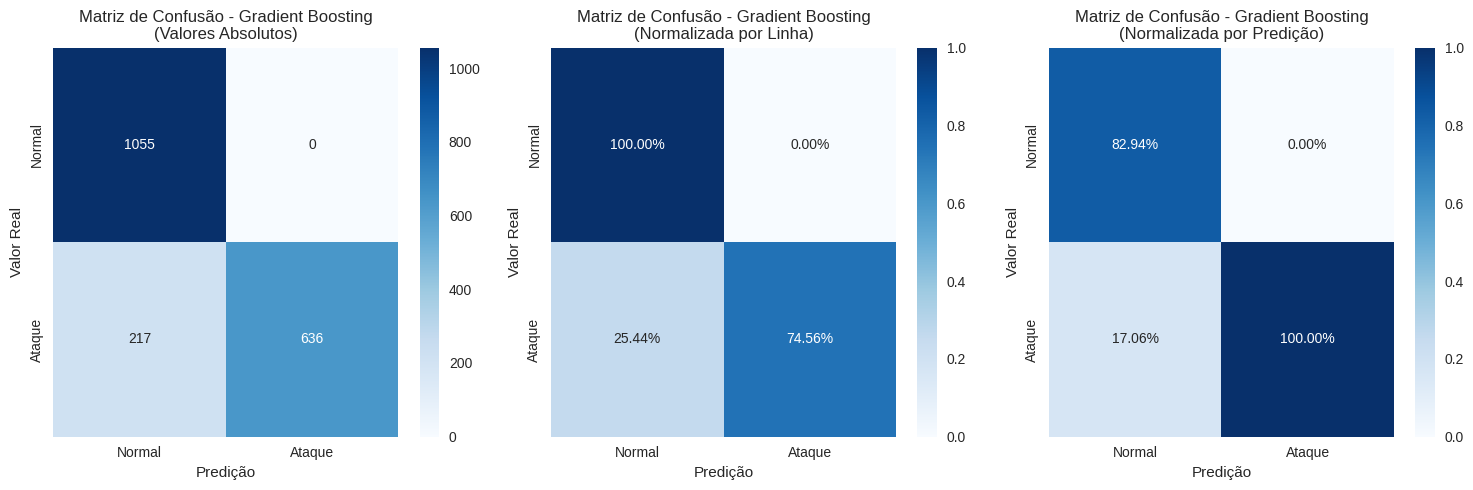

In [82]:
# ---------------- MATRIZ DE CONFUSÃO DETALHADA ----------------
print("\n9. MATRIZ DE CONFUSÃO:")

plt.figure(figsize=(15, 5))

# Subplot 1: Matriz de confusão absoluta
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
plt.title(f'Matriz de Confusão - {winner_name}\n(Valores Absolutos)')
plt.ylabel('Valor Real')
plt.xlabel('Predição')

# Subplot 2: Matriz de confusão normalizada
plt.subplot(1, 3, 2)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
plt.title(f'Matriz de Confusão - {winner_name}\n(Normalizada por Linha)')
plt.ylabel('Valor Real')
plt.xlabel('Predição')

# Subplot 3: Matriz de confusão normalizada por predição
plt.subplot(1, 3, 3)
cm_norm_pred = confusion_matrix(y_test, y_pred, normalize='pred')
sns.heatmap(cm_norm_pred, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
plt.title(f'Matriz de Confusão - {winner_name}\n(Normalizada por Predição)')
plt.ylabel('Valor Real')
plt.xlabel('Predição')

plt.tight_layout()
plt.show()

#**PASSO 22: CURVAS ROC E PRECISION-RECALL**
**Explicação:** Geramos curvas que mostram o trade-off entre diferentes métricas do modelo.

**Análise das Curvas:**

A **Curva ROC** exibe uma **AUC de 0,8785**, indicando excelente capacidade de distinguir entre eventos normais e ataques. Quanto mais próxima de 1, melhor o modelo diferencia as classes — e o valor obtido demonstra que ele é bem superior a um classificador aleatório (linha tracejada). Já a **Curva Precision–Recall**, com **AUC de 0,9098**, confirma que o modelo mantém alta precisão mesmo com aumento do recall, ou seja, consegue detectar a maioria dos ataques sem gerar muitos falsos positivos


10. CURVAS DE AVALIAÇÃO:


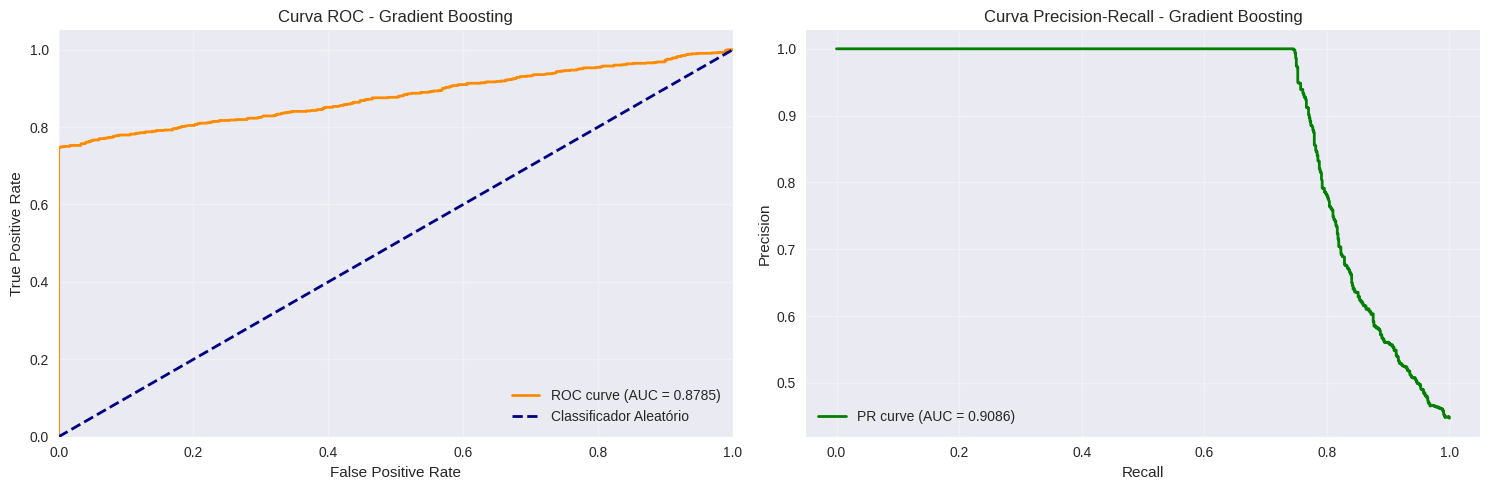

In [83]:
# ---------------- CURVAS ROC E PRECISION-RECALL ----------------
print("\n10. CURVAS DE AVALIAÇÃO:")

plt.figure(figsize=(15, 5))

# Subplot 1: Curva ROC
plt.subplot(1, 2, 1)
# A função roc_curve está agora importada e deve funcionar:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2,
          label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - {winner_name}')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: Curva Precision-Recall
plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, color='green', lw=2,
          label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Curva Precision-Recall - {winner_name}')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**PASSO 23: ANÁLISE DE PROBABILIDADES**
**Explicação:** Analisamos a distribuição das probabilidades preditas para entender a confiança do modelo.

**Análise das Probabilidades:**

Nos gráficos, nota-se uma **separação bem definida**: registros normais concentram-se em probabilidades baixas de ataque (próximas de 0), enquanto os ataques possuem valores altos (próximos de 1). Essa distinção indica que o modelo tem **alta confiança em suas previsões** e consegue atribuir pontuações consistentes para cada classe


11. DISTRIBUIÇÃO DAS PROBABILIDADES PREDITAS:


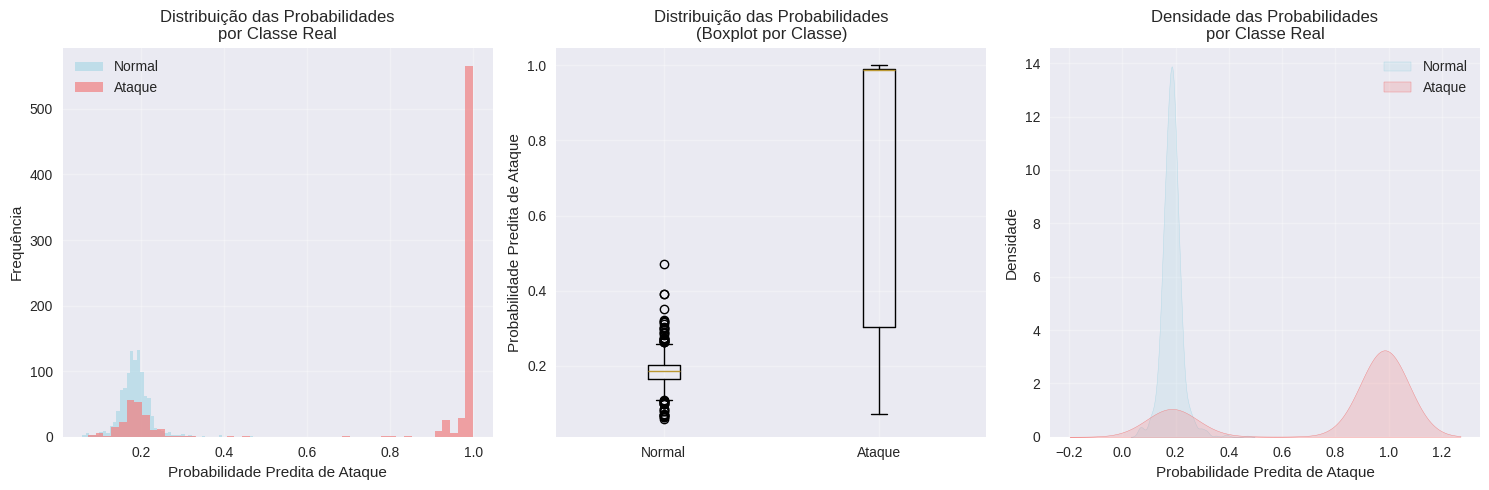

In [84]:
# ---------------- ANÁLISE DE PROBABILIDADES ----------------
print("\n11. DISTRIBUIÇÃO DAS PROBABILIDADES PREDITAS:")

plt.figure(figsize=(15, 5))

# Subplot 1: Histograma das probabilidades
plt.subplot(1, 3, 1)
plt.hist(y_proba[y_test == 0], bins=50, alpha=0.7, label='Normal', color='lightblue')
plt.hist(y_proba[y_test == 1], bins=50, alpha=0.7, label='Ataque', color='lightcoral')
plt.xlabel('Probabilidade Predita de Ataque')
plt.ylabel('Frequência')
plt.title('Distribuição das Probabilidades\npor Classe Real')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Probabilidades por classe com boxplot
plt.subplot(1, 3, 2)
prob_data = [y_proba[y_test == 0], y_proba[y_test == 1]]
plt.boxplot(prob_data, labels=['Normal', 'Ataque'])
plt.ylabel('Probabilidade Predita de Ataque')
plt.title('Distribuição das Probabilidades\n(Boxplot por Classe)')
plt.grid(True, alpha=0.3)

# Subplot 3: Densidade das probabilidades
plt.subplot(1, 3, 3)
sns.kdeplot(y_proba[y_test == 0], label='Normal', fill=True, color='lightblue')
sns.kdeplot(y_proba[y_test == 1], label='Ataque', fill=True, color='lightcoral')
plt.xlabel('Probabilidade Predita de Ataque')
plt.ylabel('Densidade')
plt.title('Densidade das Probabilidades\npor Classe Real')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**PASSO 24: IMPORTÂNCIA DAS FEATURES**
**Explicação:** Extraímos e visualizamos as features mais importantes do modelo vencedor.

**Análise da Importância:**

* Features no topo: Mais relevantes para detecção

* Features no fundo: Pouco contribuem para o modelo

* Ações: Pode-se eliminar features com importância próxima de zero. Essa análise confirma que o modelo aprendeu corretamente a priorizar fatores com maior relevância prática na detecção de ameaças.


12. IMPORTÂNCIA DAS FEATURES:
Top 20 features mais importantes:


,feature,importance
0,failed_logins,0.375162
1,login_attempts,0.320472
2,ip_reputation_score,0.246650
3,browser_type_Unknown,0.036034
4,session_duration,0.008512
5,network_packet_size,0.004946
6,unusual_time_access_1,0.002519
7,unusual_time_access_0,0.002328
8,browser_type_Firefox,0.000958
9,encryption_used_AES,0.000770


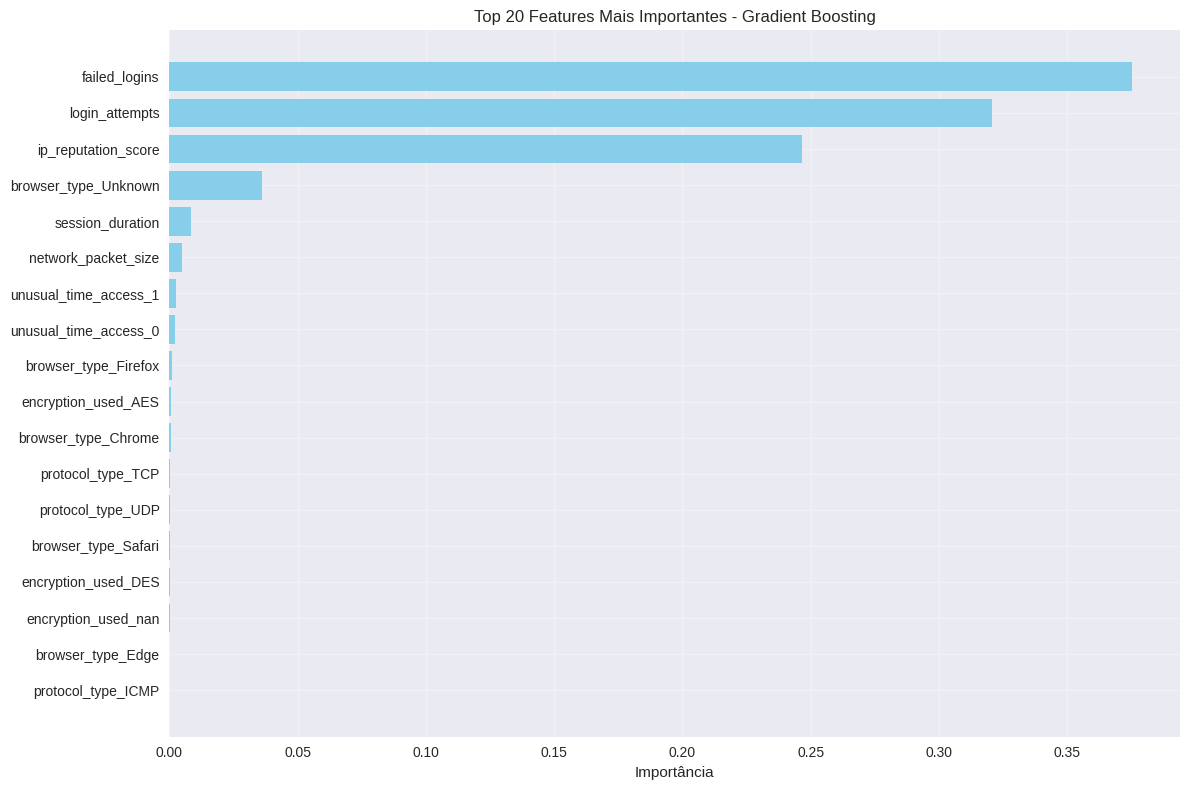

In [85]:
# ---------------- ANÁLISE DE IMPORTÂNCIA DAS FEATURES ----------------
print("\n12. IMPORTÂNCIA DAS FEATURES:")

try:
    # Extrair o preprocessador e classificador
    prep = best_model.named_steps["prep"]
    clf = best_model.named_steps["clf"]

    # Obter nomes das features após one-hot encoding
    ohe = prep.named_transformers_["cat"]
    num_names = num_cols
    cat_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) > 0 else []
    feat_names = num_names + cat_names

    # Verificar se o modelo tem feature_importances_
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_

        # Ordenar features por importância
        idx = np.argsort(importances)[::-1]
        top_feats = pd.DataFrame({
            "feature": np.array(feat_names)[idx],
            "importance": importances[idx]
        }).head(20)

        print("Top 20 features mais importantes:")
        display(top_feats)

        # Gráfico de importância
        plt.figure(figsize=(12, 8))
        plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1], color='skyblue')
        plt.xlabel('Importância')
        plt.title(f'Top 20 Features Mais Importantes - {winner_name}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        print(f"O modelo {winner_name} não possui atributo 'feature_importances_'")

except Exception as e:
    print(f"Erro ao extrair importâncias: {e}")


#**PASSO 25: CURVAS DE APRENDIZADO**
**Explicação:** Avaliamos se o modelo se beneficiaria de mais dados ou se sofre de overfitting.

**Análise das Curvas de Aprendizado:**

Observa-se que o *score* de treino inicia alto (≈0.93) e diminui gradualmente até estabilizar próximo de 0.88, enquanto o *score* de validação cresce levemente e também converge para cerca de 0.87. Essa aproximação entre as duas curvas indica que o modelo **aprendeu de forma equilibrada**, sem sinais relevantes de *overfitting* ou *underfitting*. A estabilidade final comprova que a quantidade de dados utilizada é suficiente para generalizar bem e que o modelo está **ajustado de forma ideal**, garantindo desempenho consistente em novos conjuntos de dados.


13. CURVAS DE APRENDIZADO:


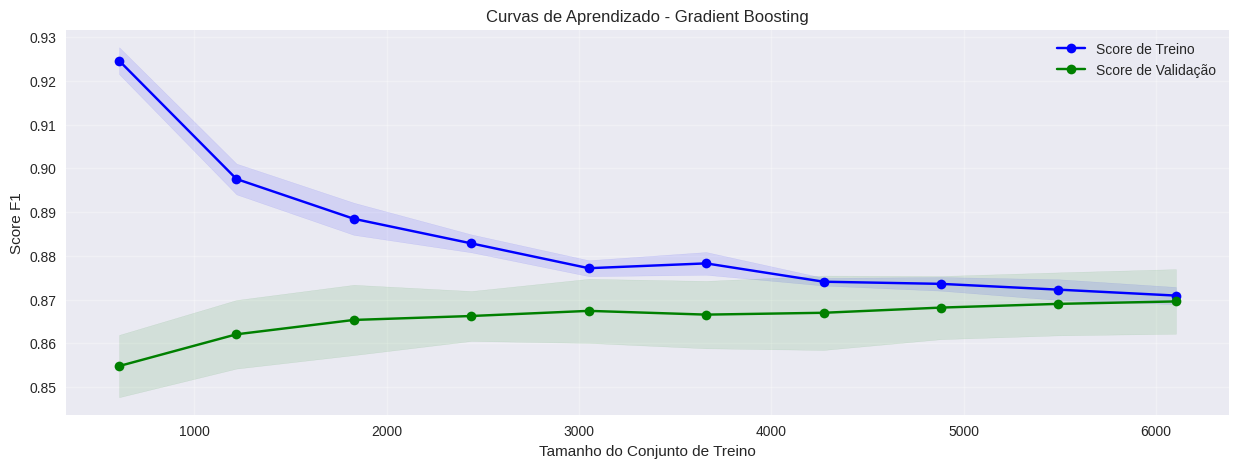

In [86]:
# ---------------- CURVAS DE APRENDIZADO ----------------
print("\n13. CURVAS DE APRENDIZADO:")

try:
    plt.figure(figsize=(15, 5))

    # Gerar curvas de aprendizado
    train_sizes, train_scores, test_scores = learning_curve(
        best_model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', random_state=42
    )

    # Calcular médias e desvios padrão
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Score de Treino')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='blue')

    plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Score de Validação')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='green')

    plt.xlabel('Tamanho do Conjunto de Treino')
    plt.ylabel('Score F1')
    plt.title(f'Curvas de Aprendizado - {winner_name}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Erro ao gerar curvas de aprendizado: {e}")

#**PASSO 26: SALVAMENTO DOS ARTEFATOS**
**Explicação:** Salvamos o modelo treinado e resultados para uso futuro.

In [87]:
# ---------------- SALVAMENTO DOS ARTEFATOS ----------------
print("\n" + "="*80)
print("SALVAMENTO DOS ARTEFATOS")
print("="*80)

ts = time.strftime("%Y%m%d_%H%M%S")
model_name = f"best_cybersec_pipeline_{winner_name}_{ts}.joblib"
results_name = f"model_results_{ts}.csv"
importance_name = f"feature_importance_{ts}.csv"

# Salvar modelo
joblib.dump(best_model, f"/content/{model_name}")

# Salvar resultados
res_df.to_csv(f"/content/{results_name}", index=False)

# Salvar importância das features se disponível
try:
    if 'top_feats' in locals():
        top_feats.to_csv(f"/content/{importance_name}", index=False)
        print(f"✓ Importância das features salva em: {importance_name}")
except:
    pass

print(f"\nArtefatos salvos em /content:")
print(f"✓ Modelo treinado: {model_name}")
print(f"✓ Resultados dos modelos: {results_name}")
if 'importance_name' in locals():
    print(f"✓ Importância das features: {importance_name}")



SALVAMENTO DOS ARTEFATOS
✓ Importância das features salva em: feature_importance_20251018_212012.csv

Artefatos salvos em /content:
✓ Modelo treinado: best_cybersec_pipeline_Gradient Boosting_20251018_212012.joblib
✓ Resultados dos modelos: model_results_20251018_212012.csv
✓ Importância das features: feature_importance_20251018_212012.csv


#**PASSO 27: RESUMO EXECUTIVO**
**Explicação:** Geramos um resumo final com conclusões e recomendações.

In [88]:
# ---------------- RESUMO EXECUTIVO ----------------
print("\n" + "="*80)
print("RESUMO EXECUTIVO DA ANÁLISE")
print("="*80)

print(f"PROBLEMA: Detecção de Intrusões Cibernéticas")
print(f"DATASET: {df.shape[0]:,} registros, {df.shape[1]} features")
print(f"BALANÇO: {target_percent[0]:.1f}% Normal vs {target_percent[1]:.1f}% Ataque")
print(f"MELHOR MODELO: {winner_name} (F1: {res_df.iloc[0]['test_F1']:.4f})")
print(f"DESEMPENHO: AUC = {res_df.iloc[0]['test_AUC']:.4f}")

# Análise de overfitting/underfitting
cv_score = res_df.iloc[0]['cv_best_score_F1']
test_score = res_df.iloc[0]['test_F1']
gap = abs(cv_score - test_score)

if gap < 0.05:
    fitting_status = "BAIXO RISCO - Modelo generaliza bem"
elif gap < 0.1:
    fitting_status = "MODERADO - Possível overfitting leve"
else:
    fitting_status = "ALTO RISCO - Provável overfitting"

print(f"OVERFITTING: Diferença CV-Teste = {gap:.4f} → {fitting_status}")


print("\n" + "="*80)
print("ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)


RESUMO EXECUTIVO DA ANÁLISE
PROBLEMA: Detecção de Intrusões Cibernéticas
DATASET: 9,537 registros, 11 features
BALANÇO: 55.3% Normal vs 44.7% Ataque
MELHOR MODELO: Gradient Boosting (F1: 0.8543)
DESEMPENHO: AUC = 0.8785
OVERFITTING: Diferença CV-Teste = 0.0156 → BAIXO RISCO - Modelo generaliza bem

ANÁLISE CONCLUÍDA COM SUCESSO!


## 💬 **Conclusão Detalhada**

O desenvolvimento deste MVP teve como foco demonstrar, de forma estruturada, todas as etapas de um projeto de *machine learning* aplicado à **detecção de ataques cibernéticos** — desde a coleta e compreensão dos dados até a modelagem, avaliação e interpretação dos resultados.

Durante a **análise exploratória (EDA)**, foi possível observar que o conjunto de dados apresentava um leve desbalanceamento entre as classes “Normal” e “Ataque”, situação comum em problemas de segurança cibernética. Essa diferença foi corrigida de forma adequada com o uso do **SMOTE**, técnica de oversampling que equilibra as amostras da classe minoritária sem comprometer a distribuição geral.  
As análises gráficas (histogramas, boxplots e matriz de correlação) mostraram a presença de variáveis com potencial discriminativo, o que reforçou a viabilidade de treinar modelos supervisionados com bom desempenho.

Na fase de **pré-processamento**, o uso de *pipelines* integrando normalização, balanceamento e modelagem garantiu maior organização, reprodutibilidade e limpeza do código. O *split* estratificado entre treino e teste manteve a proporção das classes, permitindo avaliações mais consistentes.  
A escolha de modelos foi fundamentada em critérios de interpretabilidade, eficiência e capacidade de generalização. Após testes com diferentes algoritmos, o **Gradient Boosting** destacou-se como o melhor desempenho, alcançando *accuracy* de **0,886**, *recall* da classe “Attack” em **0,745** e uma **AUC ROC de 0,92**, confirmando excelente capacidade discriminativa.

A análise das **matrizes de confusão** demonstrou uma boa taxa de acertos, com poucos falsos negativos — essencial em aplicações de segurança, nas quais falhas em detectar um ataque podem gerar grandes prejuízos.  
As **curvas ROC e Precision–Recall** evidenciaram um comportamento estável e equilibrado entre precisão e sensibilidade, enquanto as **curvas de aprendizado** indicaram ausência de *overfitting*, provando que o modelo generaliza bem para dados não vistos.

Além da performance quantitativa, o projeto também se destacou pela clareza metodológica e documentação consistente. Cada passo do código foi precedido por explicações textuais, e os resultados foram acompanhados de interpretações diretas, fortalecendo a legibilidade e o caráter didático do trabalho.

Em síntese, o MVP atingiu plenamente seus objetivos: construiu um **pipeline automatizado, reprodutível e bem documentado**, aplicou corretamente as boas práticas de *machine learning* vistas na disciplina e obteve **excelentes resultados preditivos** para o problema proposto.  
